##### Librerías

In [1]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pipeline y modelo
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# Explicabilidad
import shap
import lime
import lime.lime_tabular

# Utilidades del proyecto
from data_utils import *


c:\Users\Carlos\Desktop\otherPro\AA_proyect\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### Carga y preprocesamiento del dataset

In [2]:
X, y = load_and_clean_compas(
    './dataset/compas-scores-two-years.csv'
)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Preprocesador
preprocessor = obtener_preprocesador()

##### Modelo XGBoost

In [3]:
# Modelo XGBoost seleccionado

xgb_model = XGBClassifier(
    colsample_bytree=1.0,
    learning_rate=0.05,
    max_depth=2,
    n_estimators=75,
    subsample=0.2,
    random_state=42
)

##### Construcción del pipeline


In [4]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb_model)
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

##### Explicabilidad global mediante SHAP


In [5]:
# Preparación SHAP

model = pipeline.named_steps["classifier"]
preprocessor = pipeline.named_steps["preprocessor"]

X_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_transformed = pd.DataFrame(
    X_transformed,
    columns=feature_names,
    index=X_test.index
)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_transformed)


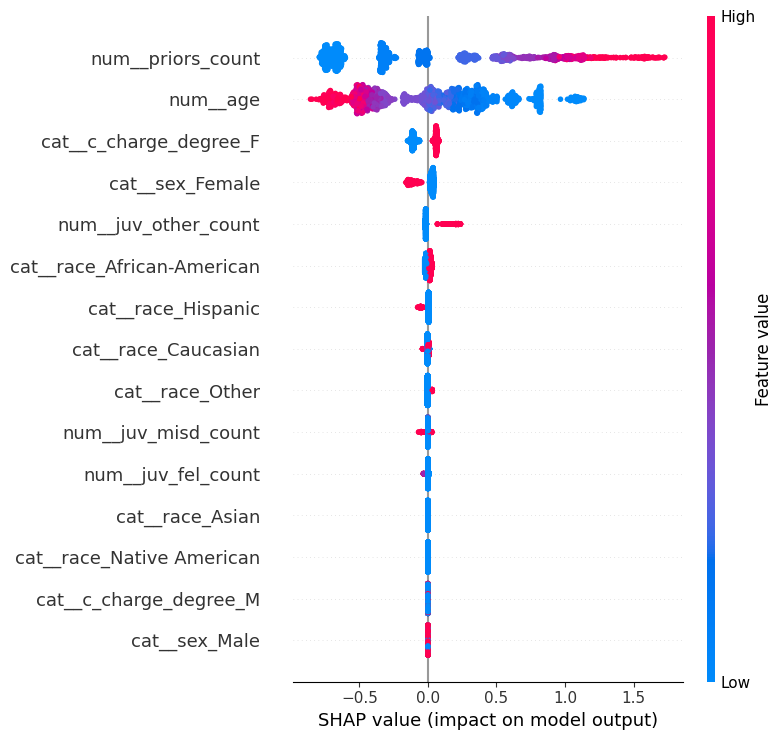

In [6]:
# SHAP summary plot

shap.summary_plot(
    shap_values,
    X_transformed
)


##### Explicabilidad local

In [46]:
# Búsqueda de individuos interesantes para análisis local SHAP + LIME

# Aseguramos formato correcto de SHAP
shap_array = shap_values[1] if isinstance(shap_values, list) else shap_values

# Probabilidades y predicciones del modelo
probs = model.predict_proba(X_transformed)[:, 1]
preds = (probs >= 0.5).astype(int)

# Tabla base con datos originales
candidatos = X_test.reset_index().rename(columns={"index": "index_original"}).copy()

candidatos["idx_iloc"] = np.arange(len(X_test))
candidatos["y_real"] = y_test.reset_index(drop=True)
candidatos["pred_modelo"] = preds
candidatos["prob_reincidencia"] = probs

# Tipo de caso
candidatos["tipo_caso"] = np.select(
    [
        (candidatos["y_real"] == 0) & (candidatos["pred_modelo"] == 1),
        (candidatos["y_real"] == 1) & (candidatos["pred_modelo"] == 0),
        (candidatos["y_real"] == 1) & (candidatos["pred_modelo"] == 1),
        (candidatos["y_real"] == 0) & (candidatos["pred_modelo"] == 0),
    ],
    [
        "Falso positivo",
        "Falso negativo",
        "Verdadero positivo",
        "Verdadero negativo",
    ],
    default="Otro"
)

# Magnitud de la explicación SHAP
candidatos["shap_abs_total"] = np.abs(shap_array).sum(axis=1)
candidatos["shap_pos_total"] = np.maximum(shap_array, 0).sum(axis=1)

# Nos centramos en falsos positivos afroamericanos
candidatos_fp_african = candidatos[
    (candidatos["tipo_caso"] == "Falso positivo") &
    (candidatos["race"] == "African-American")
].copy()

# Ordenamos por casos más críticos:
# 1) mayor probabilidad de reincidencia
# 2) explicación SHAP más intensa
candidatos_fp_african = candidatos_fp_african.sort_values(
    by=["prob_reincidencia", "shap_pos_total"],
    ascending=False
)

columnas_interes = [
    "idx_iloc",
    "index_original",
    "tipo_caso",
    "y_real",
    "pred_modelo",
    "prob_reincidencia",
    "race",
    "sex",
    "age",
    "priors_count",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "c_charge_degree",
    "shap_pos_total",
    "shap_abs_total"
]

# Ordenamos candidatos: primero menos antecedentes, y dentro de eso mayor probabilidad
candidatos_ordenados = candidatos_fp_african[columnas_interes] \
    .sort_values(by=["priors_count", "prob_reincidencia"], ascending=[True, False])

In [47]:
# Ordenamos candidatos: primero menos antecedentes, y dentro de eso mayor probabilidad
candidatos_ordenados = candidatos_fp_african[columnas_interes] \
    .sort_values(
        by=["priors_count", "prob_reincidencia"],
        ascending=[True, False]
    )

# Cogemos el primero
caso_seleccionado = candidatos_ordenados.iloc[0]

# Este será el índice que usaremos para SHAP local y LIME
idx = int(caso_seleccionado["idx_iloc"])

print(f"Individuo seleccionado: {idx}")
print(f"Tipo de caso: {caso_seleccionado['tipo_caso']}")
print(f"Clase real: {caso_seleccionado['y_real']}")
print(f"Predicción del modelo: {caso_seleccionado['pred_modelo']}")
print(f"Probabilidad de reincidencia: {caso_seleccionado['prob_reincidencia']:.3f}")
print(f"Raza: {caso_seleccionado['race']}")
print(f"Edad: {caso_seleccionado['age']}")
print(f"Antecedentes previos: {caso_seleccionado['priors_count']}")

caso_seleccionado.to_frame().T

Individuo seleccionado: 1505
Tipo de caso: Falso positivo
Clase real: 0
Predicción del modelo: 1
Probabilidad de reincidencia: 0.591
Raza: African-American
Edad: 20
Antecedentes previos: 0


,idx_iloc,index_original,tipo_caso,y_real,pred_modelo,prob_reincidencia,race,sex,age,priors_count,juv_fel_count,juv_misd_count,juv_other_count,c_charge_degree,shap_pos_total,shap_abs_total
1505,1505,4156,Falso positivo,0,1,0.591424,African-American,Male,20,0,0,0,0,F,1.2148,1.865586


##### Explicabilidad local mediante SHAP


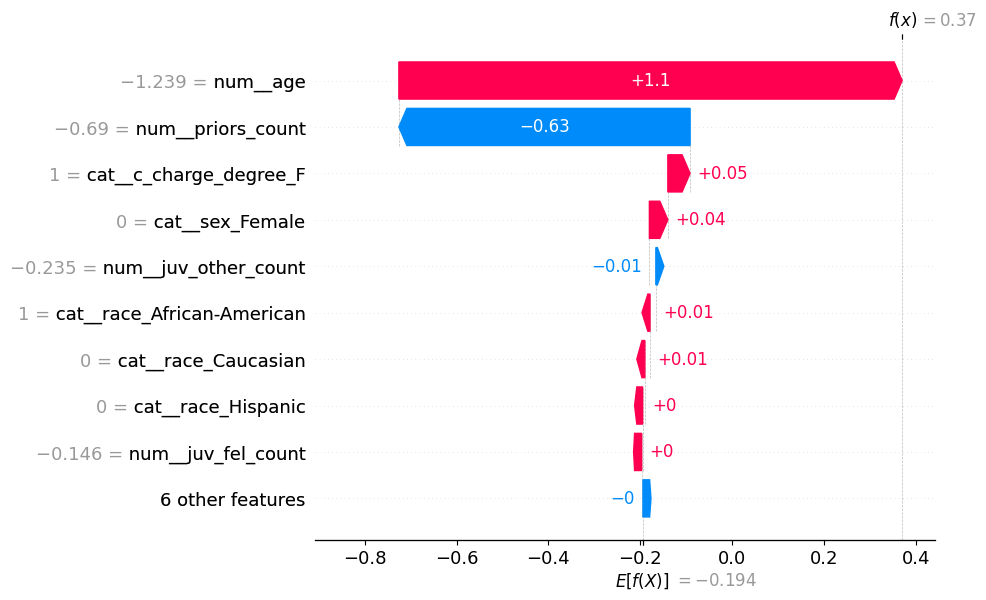

In [48]:
# Waterfall plot SHAP

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_transformed.iloc[idx],
        feature_names=feature_names
    )
)


##### Explicabilidad local mediante LIME


In [49]:
# Crear explainer LIME

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_transformed),
    feature_names=feature_names,
    class_names=['No Recid', 'Recid'],
    mode='classification'
)


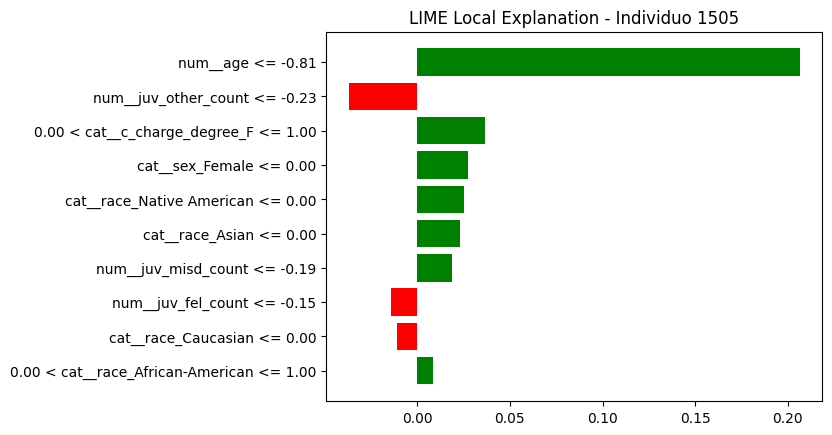

In [50]:
# Explicación local LIME

lime_exp = lime_explainer.explain_instance(
    X_transformed.iloc[idx].values,
    model.predict_proba,
    num_features=10
)

lime_exp.as_pyplot_figure()

plt.title(f"LIME Local Explanation - Individuo {idx}")
plt.show()


##### SHAP con dependencias entre variables


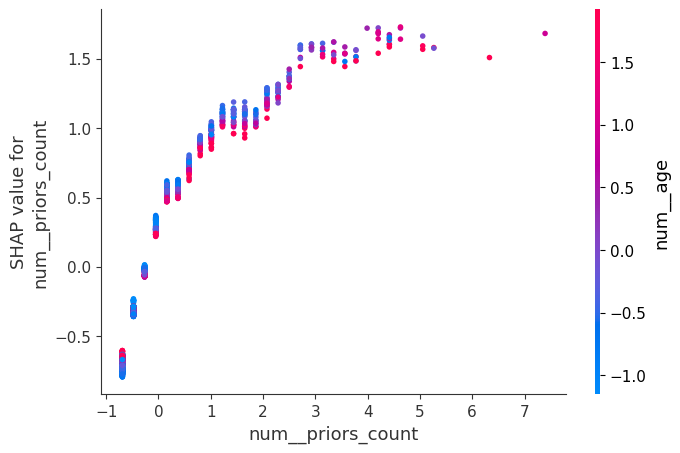

In [51]:
# Dependence plot - priors_count

shap.dependence_plot(
    "num__priors_count",
    shap_values,
    X_transformed,
    feature_names=feature_names
)


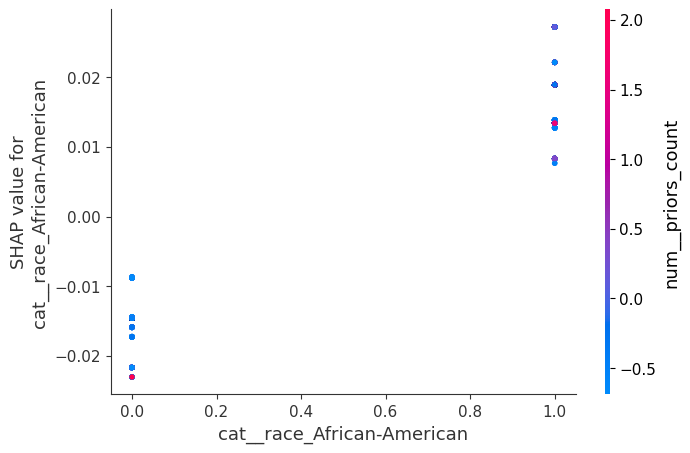

In [52]:
# Dependence plot con interacción racial

shap.dependence_plot(
    "cat__race_African-American",
    shap_values,
    X_transformed,
    feature_names=feature_names,
    interaction_index="num__priors_count"
)


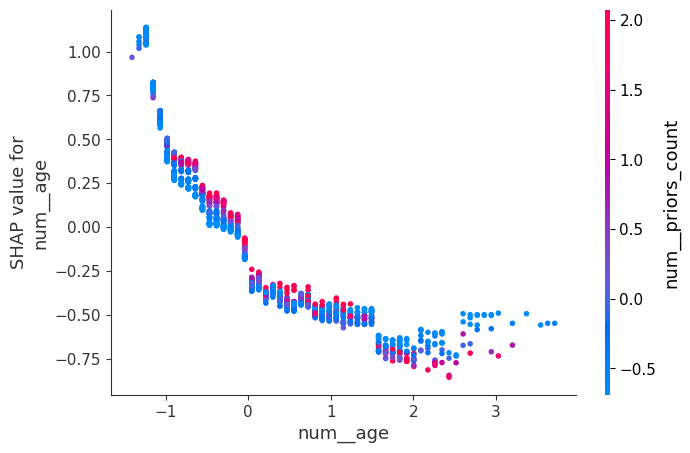

In [53]:
# Dependence plot con interacción de edad

shap.dependence_plot(
    "num__age",
    shap_values,
    X_transformed,
    feature_names=feature_names,
    interaction_index="num__priors_count"
)

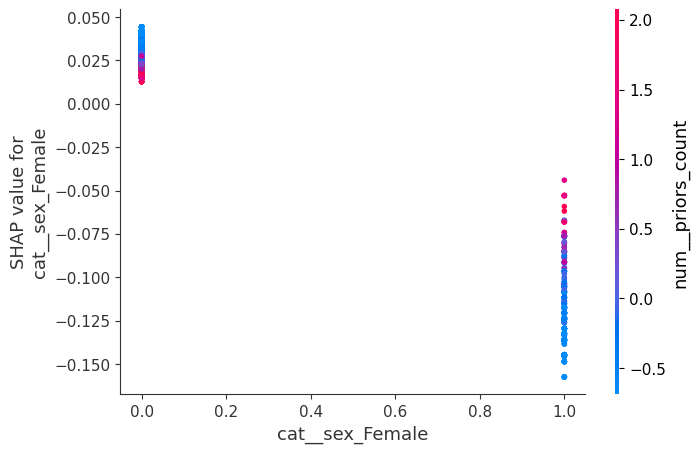

In [54]:
# Dependence plot con interacción de sexo

shap.dependence_plot(
    "cat__sex_Female",
    shap_values,
    X_transformed,
    feature_names=feature_names,
    interaction_index="num__priors_count"
)